# Dataset Visualizations

Visualizes structural properties of census, capture24, and COMPAS that explain why the RL method works well on the first two and poorly on the third.

**Figures:**
1. PCA scatter — 4-group coloring (DA−, DA+, A−, A+) with KDE contours for DA+ vs A+
2. Origin proximity — where does the PCA origin (RL start point) sit relative to DA+ and A+ centroids?
3. Alpha confidence — P(y=1) distribution at DA+ vs A+ training points
4. Group counts — train/val/test breakdown, shows the scarcity regime
5. Per-group ROC curves from alpha — where the TPR gap originates
6. Summary table — centroid distance, confidence, DA+ count per dataset

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_curve, auc

sys.path.insert(0, str(Path.cwd()))
from dataset import Dataset
from agents.ffnn_agent2 import FFNNModel

Path('analysis_figures').mkdir(exist_ok=True)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 120,
})
DEVICE = torch.device('cpu')

# 4-group palette: DA−, DA+, A−, A+
COLORS = {
    'da_neg': '#aec6e8',
    'da_pos': '#1f77b4',
    'a_neg':  '#f5c6a0',
    'a_pos':  '#d62728',
}
TITLES = {'census': 'Census Income', 'capture24': 'Capture-24', 'compas': 'COMPAS'}

In [2]:
# ── Dataset + alpha model config ──────────────────────────────────────────────
RUNS = Path('training_runs')

DATASETS = {
    'census': dict(
        dataset_name='census_income',
        da_pct=0.01433,
        real_data_size=3000,
        pca_components=10,
        minority_id=0,    # female = disadvantaged
        majority_id=1,
        seed=42,
        disadv_label='Female',
        adv_label='Male',
        alpha_dir=RUNS / 'SPECcensus_wgl_k10_5000ep_EP5000_PCA10_REWwgl_minID0_majID1_TRJ2000_REAL3000_GG202604132300_97dd3630' / 'seed_42',
        ds_kwargs=dict(use_pca=True),
        split_kwargs=dict(drop_protected=False),
    ),
    'capture24': dict(
        dataset_name='capture24',
        da_pct=0.015,
        real_data_size=3000,
        pca_components=10,
        minority_id=1,    # female = disadvantaged (a=1)
        majority_id=0,
        seed=42,
        disadv_label='Female',
        adv_label='Male',
        alpha_dir=RUNS / 'SPECcapture24_wgl_k10_5000ep_EP5000_PCA10_REWwgl_minID1_majID0_TRJ2000_REAL3000_GG202604140000_99396ee7' / 'seed_42',
        ds_kwargs=dict(use_pca=True),
        split_kwargs=dict(drop_protected=False, win_seconds=1.0, step_seconds=0.5),
    ),
    'compas': dict(
        dataset_name='compas',
        da_pct=0.014,
        real_data_size=3000,
        pca_components=10,
        minority_id=0,
        majority_id=1,
        seed=42,
        disadv_label='Disadv.',
        adv_label='Adv.',
        alpha_dir=RUNS / 'SPECcompas_wgl_k10_5000ep_EP5000_PCA10_REWwgl_minID0_majID1_TRJ2000_REAL3000_GG202604132237_80bc39af' / 'seed_42',
        ds_kwargs=dict(use_pca=True),
        split_kwargs=dict(drop_protected=False, dp_protected_col='race'),
    ),
}

In [3]:
# ── Load datasets  (capture24 takes ~1-2 min due to windowing) ────────────────

loaded = {}

for name, cfg in DATASETS.items():
    print(f'Loading {name}...')
    ds = Dataset(
        cfg['dataset_name'],
        multiclass=False,
        minority_id=cfg['minority_id'],
        majority_id=cfg['majority_id'],
        third_id=None,
        pca_components=cfg['pca_components'],
        seed=cfg['seed'],
        device=DEVICE,
        **cfg['ds_kwargs'],
    )
    splits = ds.get_data_splits(
        train_size=cfg['real_data_size'],
        da_pct=cfg['da_pct'],
        pca_components=cfg['pca_components'],
        protected_cols=ds.protected_attributes,
        **cfg['split_kwargs'],
    )
    x_tr, x_val, x_te, y_tr, y_val, y_te = splits

    X_tr  = x_tr.numpy();   y_tr_  = y_tr.numpy();   a_tr  = ds.a_train.numpy()
    X_val = x_val.numpy();  y_val_ = y_val.numpy();  a_val = ds.a_val.numpy()
    X_te  = x_te.numpy();   y_te_  = y_te.numpy();   a_te  = ds.a_test.numpy()

    disadv, adv = cfg['minority_id'], cfg['majority_id']

    def _cnt(a, y, g, c): return int(((a == g) & (y == c)).sum())

    loaded[name] = dict(
        X_tr=X_tr, y_tr=y_tr_, a_tr=a_tr,
        X_te=X_te, y_te=y_te_, a_te=a_te,
        groups_tr={
            'da_neg': X_tr[(a_tr == disadv) & (y_tr_ == 0)],
            'da_pos': X_tr[(a_tr == disadv) & (y_tr_ == 1)],
            'a_neg':  X_tr[(a_tr == adv)    & (y_tr_ == 0)],
            'a_pos':  X_tr[(a_tr == adv)    & (y_tr_ == 1)],
        },
        counts={
            split: {k: _cnt(a, y, g, c)
                    for k, (g, c) in [('DA−',(disadv,0)),('DA+',(disadv,1)),('A−',(adv,0)),('A+',(adv,1))]}
            for split, (a, y) in [('train',(a_tr,y_tr_)),('val',(a_val,y_val_)),('test',(a_te,y_te_))]
        },
        disadv=disadv, adv=adv,
    )
    c = loaded[name]['counts']
    print(f'  train DA+={c["train"]["DA+"]}  A+={c["train"]["A+"]}  '
          f'val DA+={c["val"]["DA+"]}  test DA+={c["test"]["DA+"]}')

print('Done.')

Loading census...


[TRAIN] size=3000, minority=674 (22.47%)
[VAL] size=6512, minority=1568 (24.08%)
[TEST] size=6513, minority=1569 (24.09%)
  train DA+=43  A+=631  val DA+=232  test DA+=244
Loading capture24...


[capture24] Cache: 992,430 windows, 40 participants
[capture24] MVPA=47,324  (4.8%),  female=505,628  (50.9%)


[TRAIN] size=3,000, MVPA=100 (3.3%), female=1,540, female_MVPA=45, male_MVPA=55
[VAL] size=3,000, MVPA=91 (3.0%), female=1,622, female_MVPA=49, male_MVPA=42
[TEST] size=211,857, MVPA=11,454 (5.4%), female=97,271, female_MVPA=5,441, male_MVPA=6,013
use_pca=True | theta_dim=10
  train DA+=45  A+=55  val DA+=49  test DA+=5441
Loading compas...
[compas] Label distribution: {0: 2795, 1: 2483}


[compas/TRAIN] size=2705, minority=1028 (38.00%)
[compas/VAL] size=1056, minority=497 (47.06%)
[compas/TEST] size=1056, minority=497 (47.06%)
  train DA+=42  A+=986  val DA+=157  test DA+=162
Done.


In [4]:
# ── Load alpha models ─────────────────────────────────────────────────────────

def load_alpha(seed_dir):
    seed_dir = Path(seed_dir)
    meta = json.loads((seed_dir / 'ffnn_meta.json').read_text())
    model = FFNNModel(meta['input_size'], meta['hidden_sizes'], meta['output_size'])
    model.load_state_dict(torch.load(seed_dir / 'alpha_state_dict.pt', map_location='cpu'))
    model.eval()
    return model

def predict_proba(model, X):
    """P(y=1) for each row of X."""
    if len(X) == 0:
        return np.array([])
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32))
        return torch.softmax(logits, dim=1)[:, 1].numpy()

alphas = {name: load_alpha(cfg['alpha_dir']) for name, cfg in DATASETS.items()}
print('Alpha models loaded.')

Alpha models loaded.


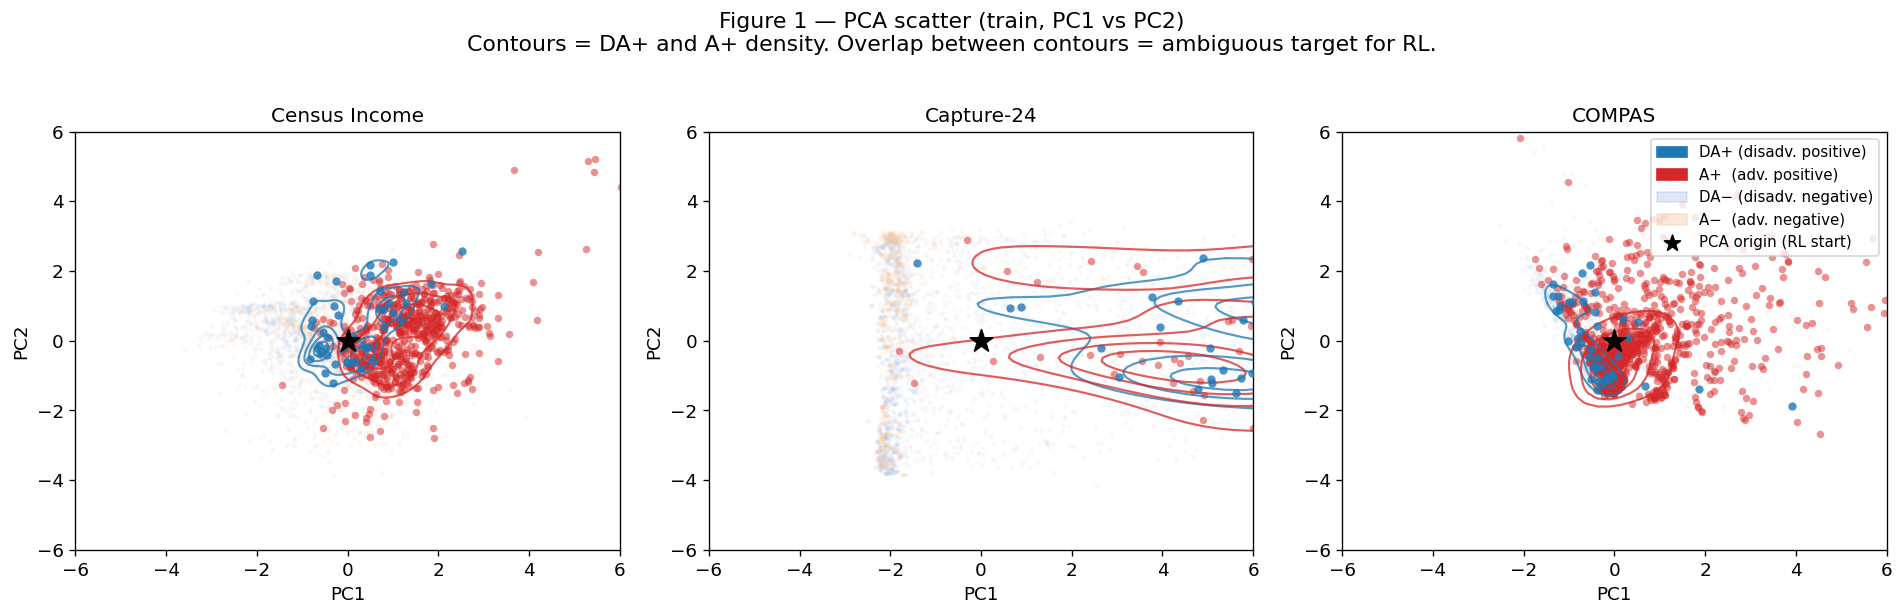

In [5]:
# ── Figure 1: PCA scatter — 4 groups + KDE contours ──────────────────────────

def kde_contour(ax, X, color, levels=4, alpha=0.75, bw=0.3):
    if len(X) < 5: return
    try:
        kde = gaussian_kde(X[:, :2].T, bw_method=bw)
        lo, hi = X[:, :2].min(0) - .5, X[:, :2].max(0) + .5
        xx, yy = np.mgrid[lo[0]:hi[0]:80j, lo[1]:hi[1]:80j]
        Z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contour(xx, yy, Z, levels=levels, colors=[color], alpha=alpha, linewidths=1.3)
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, cfg) in zip(axes, DATASETS.items()):
    g = loaded[name]['groups_tr']

    for key, alpha_val, s, zo in [
        ('da_neg', 0.12, 7,  1), ('a_neg',  0.12, 7,  1),
        ('a_pos',  0.50, 20, 2), ('da_pos', 0.80, 25, 3),
    ]:
        if len(g[key]):
            ax.scatter(g[key][:,0], g[key][:,1], c=COLORS[key],
                       s=s, alpha=alpha_val, zorder=zo, linewidths=0)

    kde_contour(ax, g['da_pos'], COLORS['da_pos'])
    kde_contour(ax, g['a_pos'],  COLORS['a_pos'])
    ax.scatter([0],[0], marker='*', s=200, c='black', zorder=10)
    ax.set(xlabel='PC1', ylabel='PC2', title=TITLES[name], xlim=(-6,6), ylim=(-6,6))

handles = [
    mpatches.Patch(color=COLORS['da_pos'], label='DA+ (disadv. positive)'),
    mpatches.Patch(color=COLORS['a_pos'],  label='A+  (adv. positive)'),
    mpatches.Patch(color=COLORS['da_neg'], label='DA− (disadv. negative)', alpha=0.4),
    mpatches.Patch(color=COLORS['a_neg'],  label='A−  (adv. negative)',    alpha=0.4),
    plt.scatter([],[], marker='*', c='black', s=100, label='PCA origin (RL start)'),
]
axes[-1].legend(handles=handles, loc='upper right', fontsize=9)
fig.suptitle('Figure 1 — PCA scatter (train, PC1 vs PC2)\n'
             'Contours = DA+ and A+ density. Overlap between contours = ambiguous target for RL.', y=1.02)
plt.tight_layout()
plt.savefig('analysis_figures/fig1_pca_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

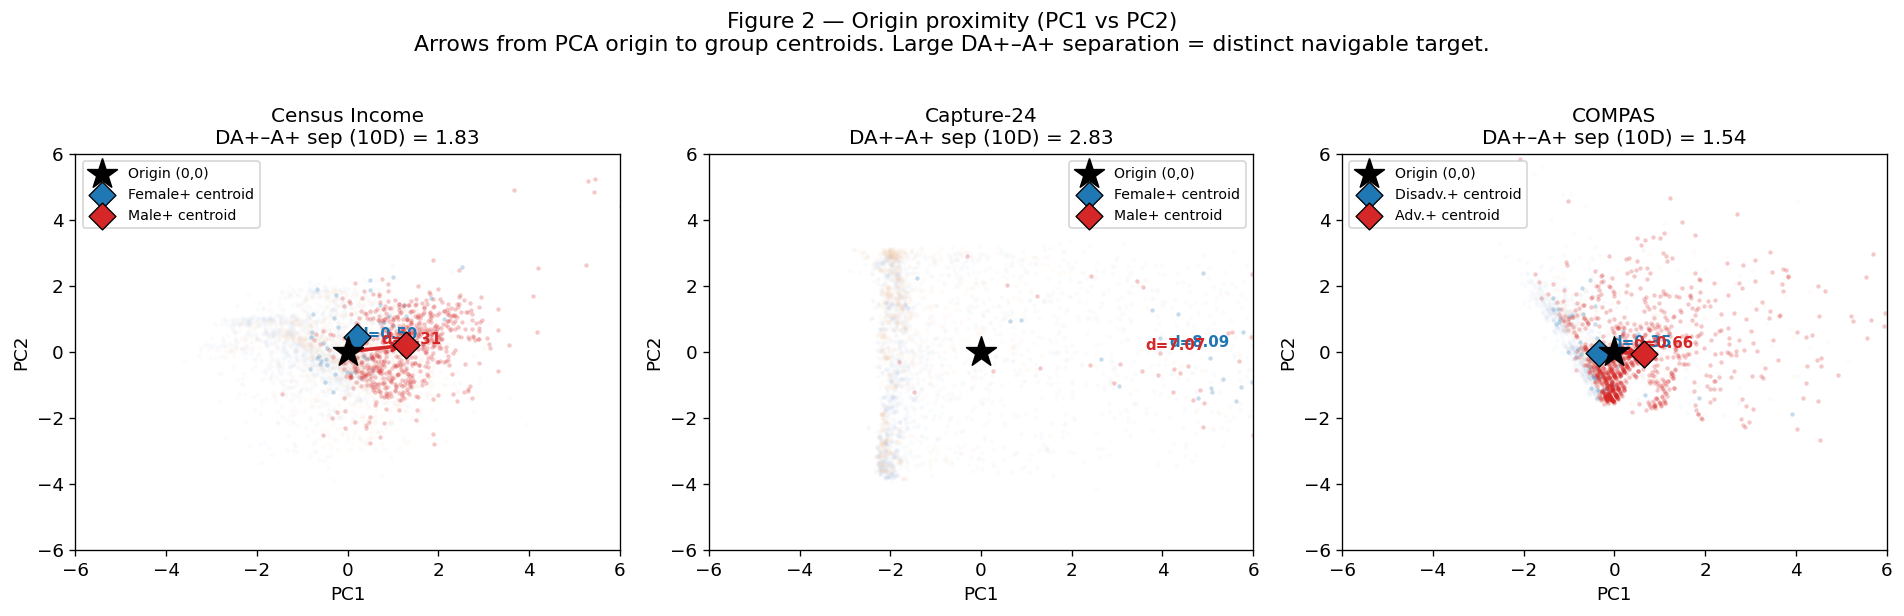

In [6]:
# ── Figure 2: Origin proximity ────────────────────────────────────────────────
# The RL agent starts every episode at (0,0) in PCA space.
# If DA+ centroid is far from A+ centroid and reachable from origin,
# the agent can learn to walk toward the DA+ region specifically.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, cfg) in zip(axes, DATASETS.items()):
    g = loaded[name]['groups_tr']

    # Faded background
    for key, a_val in [('da_neg',0.06),('a_neg',0.06),('da_pos',0.25),('a_pos',0.25)]:
        if len(g[key]):
            ax.scatter(g[key][:,0], g[key][:,1], c=COLORS[key], s=7,
                       alpha=a_val, linewidths=0)

    origin = np.zeros(2)
    ax.scatter(*origin, marker='*', s=350, c='black', zorder=10, label='Origin (0,0)')

    centroids = {}
    for key, color, lbl in [
        ('da_pos', COLORS['da_pos'], f"{cfg['disadv_label']}+ centroid"),
        ('a_pos',  COLORS['a_pos'],  f"{cfg['adv_label']}+ centroid"),
    ]:
        if len(g[key]) == 0: continue
        c2d = g[key][:, :2].mean(axis=0)
        centroids[key] = g[key].mean(axis=0)  # full 10D for distance
        dist = np.linalg.norm(c2d - origin)
        ax.scatter(*c2d, marker='D', s=130, c=color, zorder=9,
                   edgecolors='black', linewidths=0.8, label=lbl)
        ax.annotate('', xy=c2d, xytext=origin,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
        mid = (origin + c2d) / 2
        ax.text(mid[0]+0.1, mid[1]+0.15, f'd={dist:.2f}', fontsize=9,
                color=color, fontweight='bold')

    sep_str = ''
    if 'da_pos' in centroids and 'a_pos' in centroids:
        sep = np.linalg.norm(centroids['da_pos'] - centroids['a_pos'])
        sep_str = f'\nDA+–A+ sep (10D) = {sep:.2f}'

    ax.set(xlabel='PC1', ylabel='PC2', title=TITLES[name]+sep_str, xlim=(-6,6), ylim=(-6,6))
    ax.legend(fontsize=8.5)

fig.suptitle('Figure 2 — Origin proximity (PC1 vs PC2)\n'
             'Arrows from PCA origin to group centroids. '
             'Large DA+–A+ separation = distinct navigable target.', y=1.02)
plt.tight_layout()
plt.savefig('analysis_figures/fig2_origin_proximity.png', bbox_inches='tight', dpi=150)
plt.show()

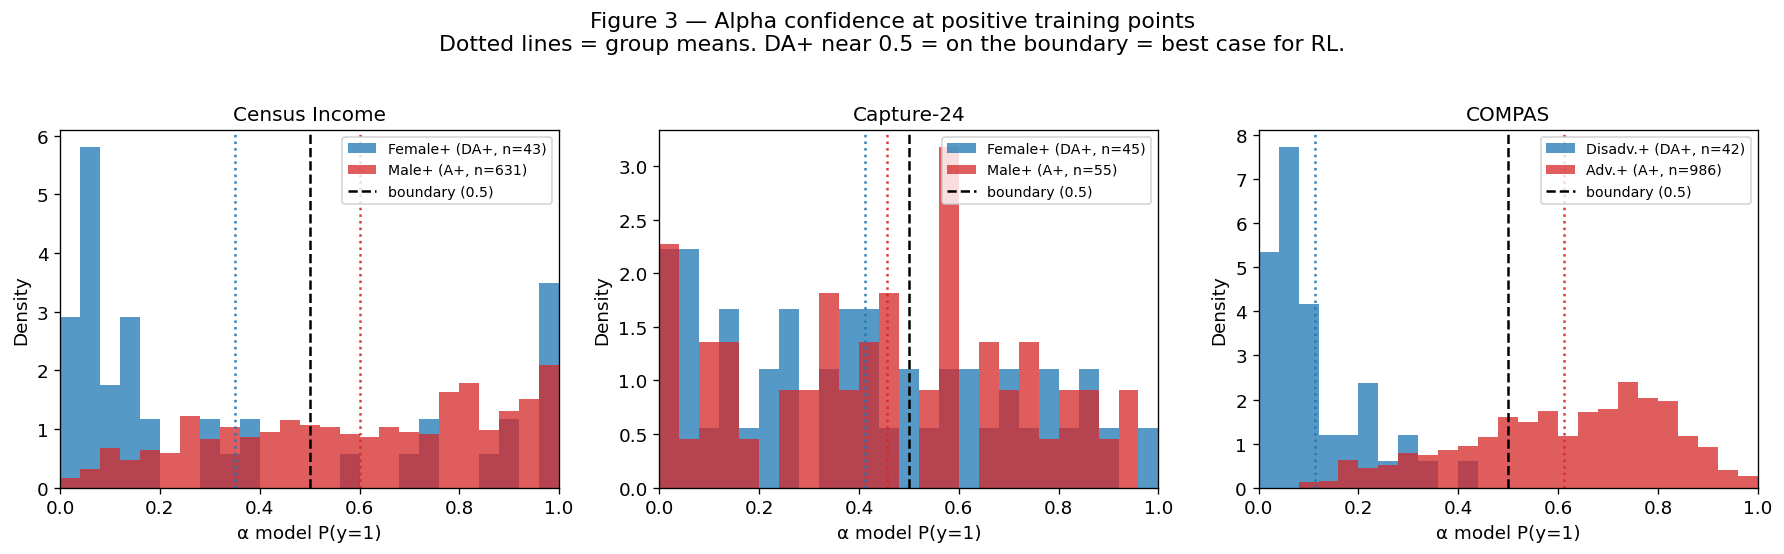

In [7]:
# ── Figure 3: Alpha confidence at DA+ vs A+ points ───────────────────────────
# P(y=1) from alpha at each training positive.
#
# Interpretation:
#  DA+ mass near 0.5 → near decision boundary → RL augmentation can shift predictions
#  DA+ mass near 0.0 → already deep in negative territory → much harder for RL to fix
#  DA+ mass near 1.0 → already well-classified → no room for improvement

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bins = np.linspace(0, 1, 26)

for ax, (name, cfg) in zip(axes, DATASETS.items()):
    g = loaded[name]['groups_tr']
    model = alphas[name]

    p_da = predict_proba(model, g['da_pos'])
    p_a  = predict_proba(model, g['a_pos'])

    ax.hist(p_da, bins=bins, color=COLORS['da_pos'], alpha=0.75,
            label=f"{cfg['disadv_label']}+ (DA+, n={len(p_da)})", density=True)
    ax.hist(p_a,  bins=bins, color=COLORS['a_pos'],  alpha=0.75,
            label=f"{cfg['adv_label']}+ (A+, n={len(p_a)})",   density=True)

    ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='boundary (0.5)')
    if len(p_da): ax.axvline(p_da.mean(), color=COLORS['da_pos'], lw=1.5, ls=':', alpha=0.9)
    if len(p_a):  ax.axvline(p_a.mean(),  color=COLORS['a_pos'],  lw=1.5, ls=':', alpha=0.9)

    ax.set(xlabel='α model P(y=1)', ylabel='Density', title=TITLES[name], xlim=(0,1))
    ax.legend(fontsize=8.5)

fig.suptitle('Figure 3 — Alpha confidence at positive training points\n'
             'Dotted lines = group means. DA+ near 0.5 = on the boundary = best case for RL.', y=1.02)
plt.tight_layout()
plt.savefig('analysis_figures/fig3_alpha_confidence.png', bbox_inches='tight', dpi=150)
plt.show()

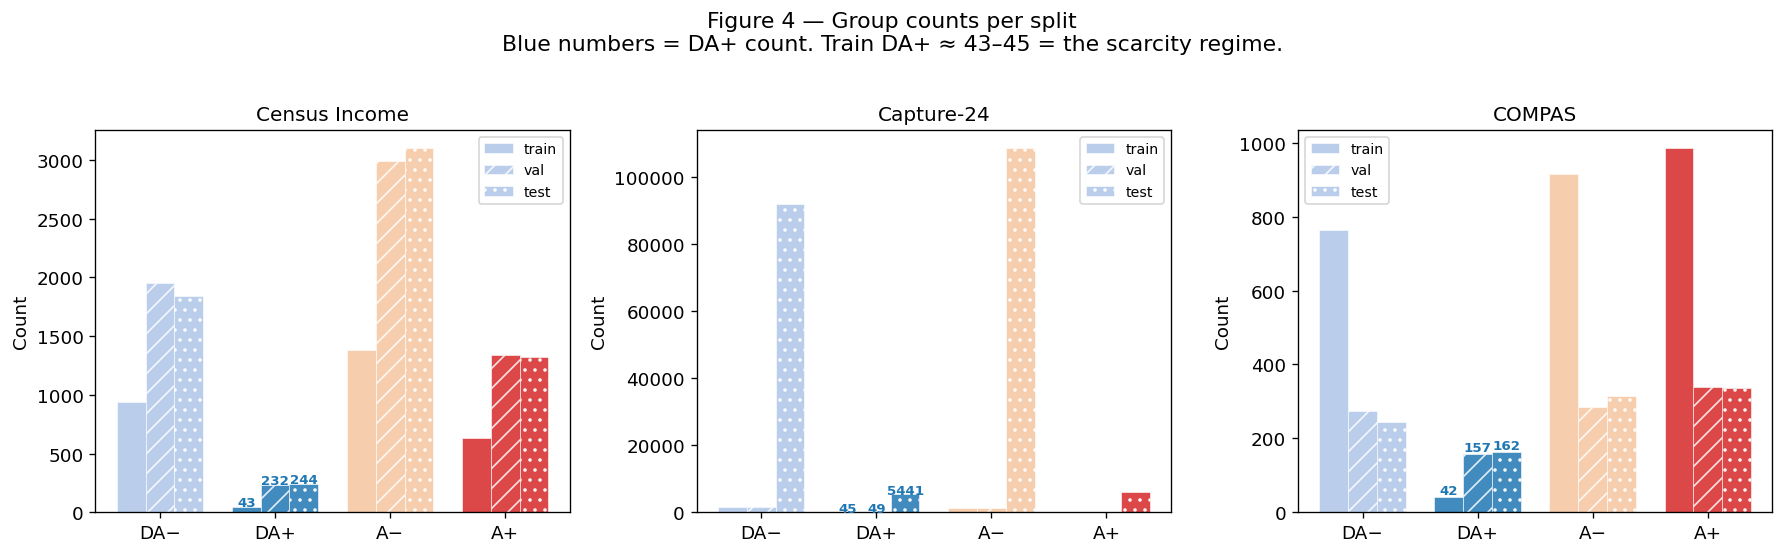

In [8]:
# ── Figure 4: Group counts — the scarcity regime ──────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bar_keys   = ['DA−', 'DA+', 'A−', 'A+']
bar_colors = [COLORS['da_neg'], COLORS['da_pos'], COLORS['a_neg'], COLORS['a_pos']]
x = np.arange(len(bar_keys))
width = 0.25

for ax, (name, cfg) in zip(axes, DATASETS.items()):
    counts = loaded[name]['counts']
    for i, (split, hatch) in enumerate([('train',''), ('val','//'), ('test','..')]):
        vals = [counts[split][k] for k in bar_keys]
        ax.bar(x + (i-1)*width, vals, width, label=split,
               color=bar_colors, alpha=0.85, hatch=hatch, edgecolor='white', linewidth=0.4)
        # annotate DA+ bar value
        ax.text(x[1] + (i-1)*width, vals[1] + 8, str(vals[1]),
                ha='center', fontsize=8, color='#1f77b4', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(bar_keys)
    ax.set(title=TITLES[name], ylabel='Count')
    ax.legend(fontsize=8.5)

fig.suptitle('Figure 4 — Group counts per split\n'
             'Blue numbers = DA+ count. Train DA+ ≈ 43–45 = the scarcity regime.', y=1.02)
plt.tight_layout()
plt.savefig('analysis_figures/fig4_group_counts.png', bbox_inches='tight', dpi=150)
plt.show()

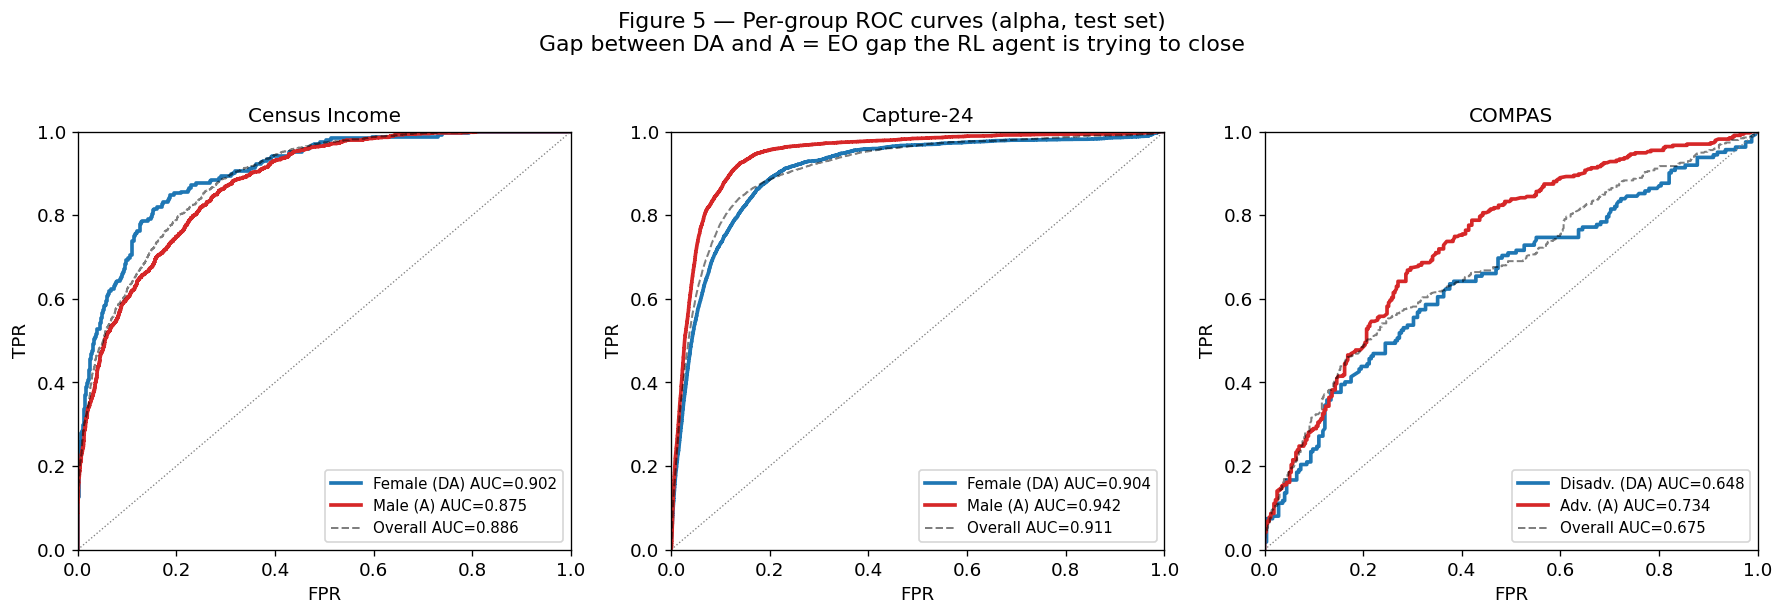

In [9]:
# ── Figure 5: Per-group ROC curves from alpha ─────────────────────────────────
# Gap between DA and A ROC curves = the EO gap.
# A large gap with DA below A confirms the unfairness the RL agent needs to close.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, cfg) in zip(axes, DATASETS.items()):
    d = loaded[name]
    model = alphas[name]
    p_te = predict_proba(model, d['X_te'])

    for group_id, color, label in [
        (d['disadv'], COLORS['da_pos'], f"{cfg['disadv_label']} (DA)"),
        (d['adv'],    COLORS['a_pos'],  f"{cfg['adv_label']} (A)"),
    ]:
        mask = d['a_te'] == group_id
        if mask.sum() == 0 or d['y_te'][mask].sum() == 0: continue
        fpr, tpr, _ = roc_curve(d['y_te'][mask], p_te[mask])
        ax.plot(fpr, tpr, color=color, lw=2.2, label=f'{label} AUC={auc(fpr,tpr):.3f}')

    fpr_all, tpr_all, _ = roc_curve(d['y_te'], p_te)
    ax.plot(fpr_all, tpr_all, 'k--', lw=1.2, alpha=0.5,
            label=f'Overall AUC={auc(fpr_all,tpr_all):.3f}')
    ax.plot([0,1],[0,1], color='grey', lw=0.8, ls=':')
    ax.set(xlabel='FPR', ylabel='TPR', title=TITLES[name], xlim=(0,1), ylim=(0,1))
    ax.legend(fontsize=9)

fig.suptitle('Figure 5 — Per-group ROC curves (alpha, test set)\n'
             'Gap between DA and A = EO gap the RL agent is trying to close', y=1.02)
plt.tight_layout()
plt.savefig('analysis_figures/fig5_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
# ── Figure 6 (summary table): separability metrics ───────────────────────────

print(f'{"Dataset":<12} {"DA+–A+ dist (10D)":>19} {"DA+ mean P(y=1)":>16} '
      f'{"A+ mean P(y=1)":>15} {"DA+ n train":>12}')
print('─' * 78)

for name, cfg in DATASETS.items():
    g = loaded[name]['groups_tr']
    model = alphas[name]

    dist_10d = np.linalg.norm(g['da_pos'].mean(0) - g['a_pos'].mean(0)) if len(g['da_pos']) and len(g['a_pos']) else float('nan')
    p_da = predict_proba(model, g['da_pos']).mean() if len(g['da_pos']) else float('nan')
    p_a  = predict_proba(model, g['a_pos']).mean()  if len(g['a_pos'])  else float('nan')

    print(f'{name:<12} {dist_10d:>19.3f} {p_da:>16.3f} {p_a:>15.3f} {len(g["da_pos"]):>12}')

print()
print('Interpretation:')
print('  DA+–A+ dist : higher = more spatially distinct target for RL agent')
print('  DA+ P(y=1)  : values near 0.5 = on decision boundary = RL augmentation most effective')
print('  DA+ n train : ~43-45 = the paper\'s scarcity regime')

Dataset        DA+–A+ dist (10D)  DA+ mean P(y=1)  A+ mean P(y=1)  DA+ n train
──────────────────────────────────────────────────────────────────────────────
census                     1.833            0.351           0.600           43
capture24                  2.826            0.412           0.456           45
compas                     1.541            0.114           0.611           42

Interpretation:
  DA+–A+ dist : higher = more spatially distinct target for RL agent
  DA+ P(y=1)  : values near 0.5 = on decision boundary = RL augmentation most effective
  DA+ n train : ~43-45 = the paper's scarcity regime
